## First regression model

Research question: How to forecast the
revenue of the next movie we create, based
on its characteristics only? 


## Load data and packages

In [549]:
import numpy as np
import pandas as pd   # We import Pandas!
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import linear_model
import torch
import itertools

import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib options
palette = itertools.cycle(sns.color_palette())
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

In [550]:
df_train= pd.read_csv('../data/movies_with_genres_and_cast_train.csv')
df_test= pd.read_csv('../data/movies_with_genres_and_cast_test.csv')
df_val= pd.read_csv('../data/movies_with_genres_and_cast_val.csv')


## Prepare data and matrix

In [551]:
print(df_train.shape, df_test.shape, df_val.shape)

(5199, 30) (1114, 30) (1115, 30)


In [552]:
X_time_train = np.concatenate([pd.get_dummies(df_train[x]).astype(float) for x in ["dow", "week"]], axis=1)
X_time_test = np.concatenate([pd.get_dummies(df_test[x]).astype(float) for x in ["dow", "week"]], axis=1)
X_time_val = np.concatenate([pd.get_dummies(df_val[x]).astype(float) for x in ["dow", "week"]], axis=1)

In [683]:
movie_caracteristics = ["genre_drama" , "genre_comedy" , "genre_thriller",
 "genre_romance", "genre_action", "genre_horror", "genre_crime",
 "genre_documentary", "genre_adventure", "genre_science_fiction", "budget"]

X_movie_train = df_train[movie_caracteristics].copy()
X_movie_test = df_test[movie_caracteristics].copy()
X_movie_val = df_val[movie_caracteristics].copy()

X_movie_train = X_movie_train.apply(pd.to_numeric, errors='coerce')
X_movie_test = X_movie_test.apply(pd.to_numeric, errors='coerce')
X_movie_val = X_movie_val.apply(pd.to_numeric, errors='coerce')

# Convert to numpy arrays
X_movie_train = X_movie_train.values
X_movie_test = X_movie_test.values
X_movie_val = X_movie_val.values

print(X_movie_train.shape)
print(X_movie_train[1])
print(X_movie_test[1])
print(X_movie_val[1])

# Note: maybe have 1/n for n the number of genre we consider only, not all genres

(5199, 11)
[0.0e+00 0.0e+00 2.5e-01 0.0e+00 2.5e-01 0.0e+00 2.5e-01 0.0e+00 2.5e-01
 0.0e+00 7.4e+06]
[0.0e+00 2.5e-01 2.5e-01 2.5e-01 2.5e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 3.5e+07]
[0.e+00 1.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
 7.e+07]


In [685]:
# create matrix with time and movie features
X_train = np.concatenate([X_time_train, X_movie_train], axis=1)
X_test = np.concatenate([X_time_test, X_movie_test], axis=1)
X_val = np.concatenate([X_time_val, X_movie_val], axis=1)
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)


(5199, 71)
(1114, 71)
(1115, 71)


In [686]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std

X_test = (X_test - X_mean) / X_std

X_val = (X_val - X_mean) / X_std


In [690]:
# prepare vector of revenue
y_train = df_train["revenue"].values
y_test = df_test["revenue"].values
y_val = df_val["revenue"].values

# standardize revenue
y_mean = y_train.mean()
y_std = y_train.std()
y_train = (y_train - y_mean) / y_std

y_test = (y_test - y_mean) / y_std

y_val = (y_val - y_mean) / y_std

## Test and error mesurement

In [691]:
def compute_error(trues, predicted):
    corr = np.corrcoef(predicted, trues)[0,1]
    mae = np.mean(np.abs(predicted - trues))
    rae = np.sum(np.abs(predicted - trues)) / np.sum(np.abs(trues - np.mean(trues)))
    rmse = np.sqrt(np.mean((predicted - trues)**2))
    r2 = max(0, 1 - np.sum((trues-predicted)**2) / np.sum((trues - np.mean(trues))**2))
    return corr, mae, rae, rmse, r2

In [692]:
#regr = linear_model.LinearRegression()
regr = linear_model.Ridge()
regr.fit(X_train, y_train)
y_hat = regr.predict(X_test)

# Convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.759
MAE: 46897232.916
RMSE: 80809661.704
R2: 0.566


## MODEL

In [693]:
def model(X, obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0, 1))                   # Prior for the bias/intercept
    beta  = pyro.sample("beta", dist.Normal(torch.zeros(X.shape[1]), 
                                            torch.ones(X.shape[1])).to_event())    # Priors for the regression coeffcients
    sigma = pyro.sample("sigma", dist.HalfCauchy(0.5))                   # Prior for the variance
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha + X.matmul(beta), sigma), obs=obs)
        
    return y

## SVI training

In [694]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train).float()

In [695]:
# Define guide function
guide = AutoMultivariateNormal(model)

# Reset parameter values
pyro.clear_param_store()

In [696]:
# Define the number of optimization steps
n_steps = 2000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model, guide, optimizer, loss=elbo)

In [697]:
# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 187855.1
[100] ELBO: 90856.6
[200] ELBO: 62258.3
[300] ELBO: 27078.1
[400] ELBO: 17900.0
[500] ELBO: 10859.8
[600] ELBO: 9362.9
[700] ELBO: 7672.2
[800] ELBO: 6891.7
[900] ELBO: 6968.0
[1000] ELBO: 6963.9
[1100] ELBO: 6480.0
[1200] ELBO: 6519.2
[1300] ELBO: 6206.3
[1400] ELBO: 6307.4
[1500] ELBO: 5983.7
[1600] ELBO: 6056.5
[1700] ELBO: 5929.7
[1800] ELBO: 5991.7
[1900] ELBO: 5955.8


In [698]:
from pyro.infer import Predictive

predictive = Predictive(model, guide=guide, num_samples=5000,
                        return_sites=("alpha", "beta", "sigma"))
samples = predictive(X_train_torch, y_train_torch)
print(samples["alpha"].shape)

torch.Size([5000, 1])


In [699]:
alpha_samples = samples["alpha"].detach().numpy()
beta_samples = samples["beta"].detach().numpy()
sigma_samples = samples["sigma"].detach().numpy()
y_hat = np.mean(alpha_samples.T + np.dot(X_test, beta_samples[:,0].T), axis=1)

# convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

print(preds.size)

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))


1114
CorrCoef: 0.755
MAE: 47688230.034
RMSE: 81308819.826
R2: 0.561


In [ ]:
# Plot true vs predicted revenue with regression line
plt.figure(figsize=(10, 6))
plt.scatter(y_true, preds, alpha=0.5, label='Predictions')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect prediction (y=x)')
plt.xlabel('True Revenue')
plt.ylabel('Predicted Revenue')
plt.title('True vs Predicted Revenue')
plt.legend()
plt.show()

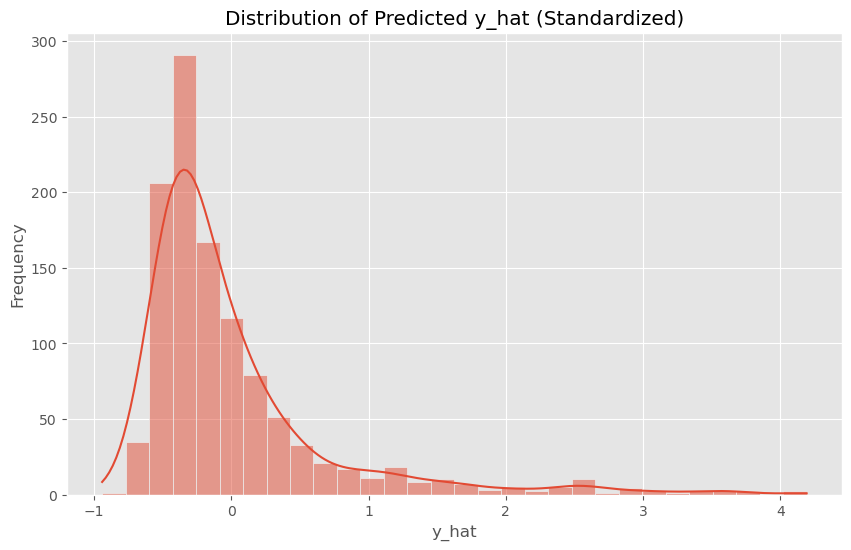

In [700]:
# Plot the distribution of y_hat (standardized predictions)
plt.figure(figsize=(10, 6))
sns.histplot(y_hat, kde=True, bins=30)
plt.title('Distribution of Predicted y_hat (Standardized)')
plt.xlabel('y_hat')
plt.ylabel('Frequency')
plt.show()